# 460 — Functional-role matching (concatenated, conjunction)

The **condition-structured** path. Each contact is the three conditions stitched in time,
`[audio | picture | reading]`. We **discretize** to a score-gated −1/0/+1 map and assign a
**functional role** only if the contact expresses **every** box of that role's conjunction
template (strict AND) — a box expresses its sign via the clustering **proportion gate** on the
−1/+1 cells. Roles live in `functions/roi_config_concatenated.py` (auditory / visual / motor /
multimodal — **draft, edit them**).

- **Auditory** = HGA in the audio **stimulus** + the **response** of all three (hears stimulus +
  hears own voice ×3). **Motor** = HGA in all three responses. **Visual** = HGA in the picture &
  reading stimuli. The discriminator is the *stimulus* boxes (response is shared motor/feedback —
  only **anatomy** separates those, which is what the POOL map shows).
- One sample per contact; **only contacts with all three conditions** enter.
- `role` = the **most specific** matching template (most boxes); `roles_matched` lists all.

> Discretization needs blob resolution, so `USE_DS=False` (full 129×300) is the faithful baseline;
> `USE_DS=True` downsamples the painted map (faster, coarser).


In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import display, Markdown, Image
sys.path.insert(0, str(Path('..').resolve()))
from functions import lf_pool as P

INPUT_DIR = Path(r'\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

print('INPUT_DIR :', INPUT_DIR, '| exists:', INPUT_DIR.exists())
print('OUTPUTS   :', P.OUTPUTS_ROOT)
print('COORDS    :', P.COORDS_DIR, '| exists:', P.COORDS_DIR.exists())
print('conditions:', P.CONDITIONS, '| zones:', P.DEFAULT_ZONES)
print('feature sets:', P.FEATURE_SETS, '| window shapes:', P.WINDOW_SHAPES)


INPUT_DIR : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY | exists: True
OUTPUTS   : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling
COORDS    : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\250_recon\fsaverage\coords | exists: True
conditions: ('audio', 'picture', 'reading') | zones: ('perception', 'pre_articulation', 'audio')
feature sets: ('hg', 'bands15') | window shapes: ('boxcar', 'gaussian')


In [2]:
# ---- knobs ----
USE_DS    = False                    # False: full-res discretized baseline (recommended) · True: ds
GRID      = 'ds' if USE_DS else 'full'
SCORE_PCT = 33.0                     # blob-score gate for the -1/0/+1 discretization
print('grid:', GRID, '| roles:', [r['role'] for r in P.ROLE_PARAMS[GRID]['roles']])


grid: full | roles: ['auditory', 'visual', 'motor', 'multimodal_sensory', 'language', 'context_extraction', 'word_search', 'alpha_beta_suppression']


## 1 — Load + resolve the discretization score gate


In [3]:
df_meta, X_full = P.prepare_pooling_dataset(INPUT_DIR)
score_min = P.resolve_score_gate(X_full, pct=SCORE_PCT)
score_min = 300
print('score gate:', score_min)


[lf_dataset cache hit] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\_dataset\pooling\_raw_ungated
  8841 samples · X_3d.shape=(8841, 129, 300)
[lf_pool] 8841 samples, 8841 with a contact key, X_3d=(8841, 129, 300)
[lf_pool] blob-score gate = 33th pct = 20.71 (15188 blobs over 4421 sampled contacts)
score gate: 300


## 2 — Concatenate + score-gated discretize (one map per all-3-condition contact)


In [4]:
df_contacts, X_disc = P.build_concat_discretized(df_meta, X_full, score_min=score_min, grid=GRID)
print('contacts:', len(df_contacts), '| X_disc:', X_disc.shape)
df_contacts.head()


[lf_pool] concat-discretized: 2856 contacts with all 3 conditions · X_disc=(2856, 129, 900)
contacts: 2856 | X_disc: (2856, 129, 900)


,patient_id,contact_norm,electrode
0,EL030,AL10,A_L10
1,EL030,AL11,A_L11
2,EL030,AL12,A_L12
3,EL030,AL13,A_L13
4,EL030,AL14,A_L14


## 3 — Conjunction role matching
A contact gets a role only if **all** that role's boxes clear the proportion gate in the expected
sign. `role` = most-specific match.


[lf_pool] roles run -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\roles\full\runs\20260612_152537
[lf_pool] role table: (2856, 7)


,role,n_contacts
0,none,2789
1,alpha_beta_suppression,59
2,context_extraction,4
3,auditory,3
4,motor,1


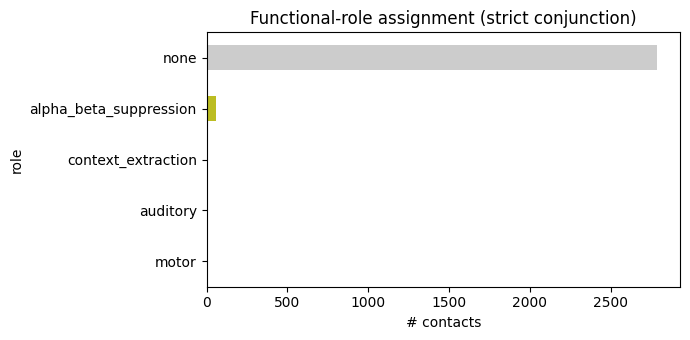

In [5]:
import matplotlib.pyplot as plt
df_role = P.build_role_table(df_contacts, X_disc, grid=GRID)
counts = P.role_counts(df_role)
display(counts)
ax = counts.set_index('role')['n_contacts'].plot.barh(figsize=(7, 0.5 * len(counts) + 1),
        color=[P.role_colors(GRID).get(r, '#888') for r in counts['role']])
ax.set_xlabel('# contacts'); ax.set_title('Functional-role assignment (strict conjunction)')
ax.invert_yaxis(); plt.tight_layout(); plt.show()


## 4 — Export for the POOL web page
Writes `contacts_pool.csv` (xyz + role + colour) + `pool_index.json` to the **stable**
`outputs/pooling/pool_web/` path that `web/pool.html` (Niivue, in your `lorafanda.github.io`
repo) reads via raw-GitHub. Reuses the MOBA fsaverage meshes. **Commit + push** that folder so
the page can fetch it.


In [6]:
coords = P.load_coords()
web = P.export_pool_web(df_role, coords, P.OUTPUTS_ROOT / 'pool_web', grid=GRID, df_meta=df_meta)
print('POOL web data ->', web)


[lf_pool] POOL web export -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_web  (2644 contacts)
POOL web data -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\pool_web
